In [2]:
import numpy as np

MAXD = 7
MAXDEL = 6
MS = 1.0
def main(data):
    N = len(data)
    mean = np.mean(data)
    sd = np.std(data, ddof=1)
    eps = sd / MS

    maxdat = np.max(data)
    data = np.concatenate(([0.0], data, [maxdat + 100 * eps]))  # data[0] y data[N+1]

    Ci = [0] * (MAXD + 1)

    for j in range(1, N + 1):
        for i in range(1, j):
            k = 0
            while k < MAXD and abs(data[i + k] - data[j + k]) <= eps:
                Ci[k + 1] += 1
                k += 1

    norm = 2.0 / (N * (N - 1))
    C = [1.0] + [Ci[i] * norm for i in range(1, MAXD + 1)]

    for i in range(1, MAXD + 1):
        print(f"C[{i}] = {Ci[i]:<10d}   c[{i}] = {C[i]:.12f}")

    gamma = [0.0] * (MAXD + 1)
    for i in range(1, MAXDEL + 1):
        denominator = C[i - 1] * C[i + 1]
        if denominator != 0:
            gamma[i] = 1.0 - (C[i] ** 2) / denominator

    print()
    for i in range(1, MAXDEL + 1):
        print(f"gamma[{i}] = {gamma[i]}")
    return gamma[1]


In [3]:
import numpy as np
from itertools import combinations

def embed_time_series(series, d):
    """Reconstruye el espacio de estados con dimensión d."""
    N = len(series)
    return np.array([series[i:i+d] for i in range(N - d + 1)])

def heaviside(x):
    return 1.0 * (x >= 0)

def I_ij(vi, vj, epsilon):
    """Función indicadora I_ij(ε)."""
    return np.prod([heaviside(epsilon - abs(vi[k] - vj[k])) for k in range(len(vi))])

def C_d(embedded, epsilon):
    """Calcula C_d(ε) para una serie embebida."""
    pairs = list(combinations(range(len(embedded)), 2))
    M = len(pairs)
    if M == 0:
        return 0
    sum_I = sum(I_ij(embedded[i], embedded[j], epsilon) for i, j in pairs)
    return sum_I / M

def gamma_j(series, j, epsilon):
    """Calcula γ_j usando C_{j-1}, C_j y C_{j+1}."""
    if j < 1:
        raise ValueError("j debe ser mayor o igual a 1")

    C_j_minus = C_d(embed_time_series(series, j - 1), epsilon)
    C_j = C_d(embed_time_series(series, j), epsilon)
    C_j_plus = C_d(embed_time_series(series, j + 1), epsilon)

    if C_j_minus * C_j_plus == 0:
        return 0
    return 1 - (C_j ** 2) / (C_j_minus * C_j_plus)


In [ ]:
def logistic_map(r, x):
    return r * x * (1 - x)
lista = []
rs = np.linspace(3.0, 4.0, 300)
for r in rs:
    orbit_values = []
    x = 0.6
    for _ in range(1000): # Converger
        # x = np.clip(x, 0.0, 1.0)
        x = logistic_map(r, x) #+ generar_uniforme_centrada(1, 1e-6)[0]
    for _ in range(500):
        # x = np.clip(x, 0.0, 1.0)
        x = logistic_map(r, x) #+ generar_uniforme_centrada(1, 1e-6)[0]
        orbit_values.append(x)

    # Generamos una serie caótica
    series = np.array(orbit_values)
    gamma1 = main(series)
    lista.append(gamma1)

# series = np.random.rand(400)
# series = np.array([3,7,1,2]*140)

mean = np.mean(series)
sd = np.std(series, ddof=1)
eps = sd / 1.0  # MS = 5.0

# for j in range(1, 3):
    # print(f"gamma[{j}] (moderno) = {gamma_j(series, j, eps):+.8f}")

C[1] = 62250        c[1] = 0.498997995992
C[2] = 62001        c[2] = 0.497002004008
C[3] = 61752        c[3] = 0.495006012024
C[4] = 61504        c[4] = 0.493018036072
C[5] = 61256        c[5] = 0.491030060120
C[6] = 61009        c[6] = 0.489050100200
C[7] = 60762        c[7] = 0.487070140281

gamma[1] = 0.498997995991984
gamma[2] = -1.6129032258005438e-05
gamma[3] = 0.0
gamma[4] = -1.6259369461701922e-05
gamma[5] = 0.0
gamma[6] = -1.639129294517261e-05
C[1] = 62250        c[1] = 0.498997995992
C[2] = 62001        c[2] = 0.497002004008
C[3] = 61752        c[3] = 0.495006012024
C[4] = 61504        c[4] = 0.493018036072
C[5] = 61256        c[5] = 0.491030060120
C[6] = 61009        c[6] = 0.489050100200
C[7] = 60762        c[7] = 0.487070140281

gamma[1] = 0.498997995991984
gamma[2] = -1.6129032258005438e-05
gamma[3] = 0.0
gamma[4] = -1.6259369461701922e-05
gamma[5] = 0.0
gamma[6] = -1.639129294517261e-05
C[1] = 62250        c[1] = 0.498997995992
C[2] = 62001        c[2] = 0.497002004008


NameError: name 'plt' is not defined

In [28]:
def generar_uniforme_centrada(n, varianza):
    # Calcular el límite superior e inferior de la distribución uniforme
    limite = np.sqrt(varianza) # varianza*3
    # Generar n números aleatorios con distribución uniforme entre -limite y limite
    return np.random.uniform(-limite, limite, n)

In [4]:
# series = np.array([0.6]*300)
# series = generar_uniforme_centrada(400,1e-5)
main(series)

C[1] = 124750       c[1] = 1.000000000000
C[2] = 124251       c[2] = 0.996000000000
C[3] = 123753       c[3] = 0.992008016032
C[4] = 123256       c[4] = 0.988024048096
C[5] = 122760       c[5] = 0.984048096192
C[6] = 122265       c[6] = 0.980080160321
C[7] = 121771       c[7] = 0.976120240481

gamma[1] = -0.004016064257028162
gamma[2] = -8.048289738438186e-06
gamma[3] = -8.080677484034737e-06
gamma[4] = -8.11326112537536e-06
gamma[5] = -8.146042245193996e-06
gamma[6] = -8.179022443322026e-06


Primer índice con valor > 0.6: 248
3.82943143812709


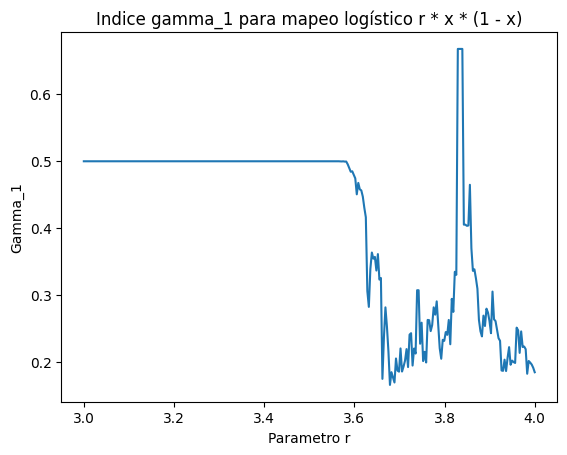

In [28]:
import matplotlib.pyplot as plt

# plt.plot([2.5,3.0,3.2,3.5,3.55,3.6,3.7,3.8,3.9,4.0],
        #  [0,0.498997995991984,0.498997995991984,0.498997995991984, 0.498997995991984,
        #   0.47757274121778903,0.18089713069217317,
        #   0.21167939228306587, 0.2629321663286075,0.18416203069355908])
plt.title(f"Indice gamma_1 para mapeo logístico r * x * (1 - x)")
plt.plot(rs, lista)
plt.xlabel('Parametro r')
plt.ylabel('Gamma_1')

lista = np.array(lista)
if np.any(lista > 0.6):
    first_index = np.where(lista > 0.6)[0][0]
    print("Primer índice con valor > 0.6:", first_index)
else:
    print("No hay valores mayores a 0.6")
print(rs[248])

array([0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.498998  ,
       0.498998  , 0.498998  , 0.498998  , 0.498998  , 0.49899

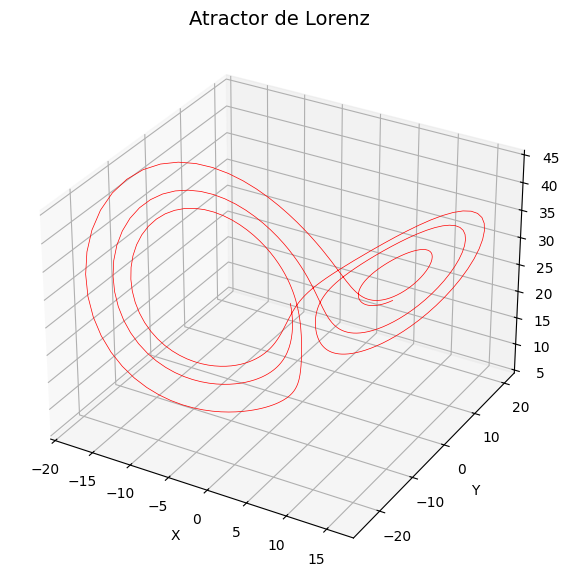

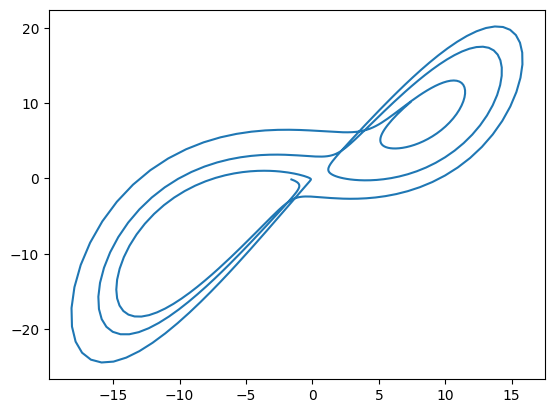

In [96]:
rho = 28.0  # Parámetro rho

import numpy as np
import matplotlib.pyplot as plt

# Parámetros del sistema
sigma = 10.0  # Parámetro sigma
beta = 8.0 / 3.0  # Parámetro beta
dt = 0.01  # Paso de integración
transitorio = 15000  # Tiempo en pasos para eliminar el transitorio
total_puntos = 15500  # Número total de pasos

# Función del sistema de Lorenz
def lorenz_system(state, sigma, beta, rho):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

# Método de Runge-Kutta de cuarto orden
def runge_kutta_step(state, dt, sigma, beta, rho):
    k1 = lorenz_system(state, sigma, beta, rho)
    k2 = lorenz_system(state + 0.5 * dt * k1, sigma, beta, rho)
    k3 = lorenz_system(state + 0.5 * dt * k2, sigma, beta, rho)
    k4 = lorenz_system(state + dt * k3, sigma, beta, rho)
    return state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

# Condición inicial
initial_state = np.array([1.0, 1.0, 1.0])

# Inicialización de arrays para almacenar resultados
states = np.zeros((total_puntos, 3))
states[0] = initial_state

# Integración numérica
for i in range(1, total_puntos):
    states[i] = runge_kutta_step(states[i - 1], dt, sigma, beta, rho)

# Eliminar el transitorio
states = states[transitorio:]

# Extraer coordenadas x, y, z
x, y, z = states[:, 0], states[:, 1], states[:, 2]

# Graficar el atractor
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.5, color='red')
ax.set_title("Atractor de Lorenz", fontsize=14)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()
plt.plot(x,y)
plt.show()


In [99]:
main(x)

C[1] = 64947        c[1] = 0.520617234469
C[2] = 62851        c[2] = 0.503815631263
C[3] = 60763        c[3] = 0.487078156313
C[4] = 58686        c[4] = 0.470428857715
C[5] = 56619        c[5] = 0.453859719439
C[6] = 54568        c[6] = 0.437418837675
C[7] = 52533        c[7] = 0.421106212425

gamma[1] = 0.4620208504708898
gamma[2] = -0.0009815692707633161
gamma[3] = -0.000994553089661121
gamma[4] = -0.0010773059290767328
gamma[5] = -0.0010409493715028972
gamma[6] = -0.0011097145008409637


rho 350 0.4578150700475896
rho 28 0.4620208504708898

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.interpolate import PchipInterpolator

def J_univariante(X, tau, corte):
    def distancia(p1, p2):
        return np.linalg.norm(np.array(p2) - np.array(p1))
    X = np.array(X)
    x1 = X[tau:]
    y1 = X[:-tau]
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))
    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([distancia(p1, c) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])
    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)
    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    return J

def J_bivariante(X, Y, corte):
    def distancia(p1, p2):
        return np.linalg.norm(np.array(p2) - np.array(p1))
    X = np.array(X)
    ff1 = np.angle(np.fft.rfft(X))
    ff2 = np.angle(np.fft.rfft(Y))
    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([distancia(p1, c) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])
    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)
    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    return J


# Tus funciones de índice J y gamma (dejadas intactas aquí)
# Asegúrate de que J_univariante(X, tau=1, corte=False) ya esté definida

MAXD = 7
MAXDEL = 6
MS = 1.0
indice_gamma = 3

def calcular_gamma_opt(data, gamma_index, MS):
    N = len(data)
    sd = np.std(data, ddof=1)
    eps = sd / MS
    maxdat = np.max(data)
    data = np.concatenate(([0.0], data, [maxdat + 100 * eps]))

    Ci = [0] * (gamma_index + 2)
    for j in range(1, N + 1):
        for i in range(1, j):
            k = 0
            while k <= gamma_index + 1 and abs(data[i + k] - data[j + k]) <= eps:
                if k in (gamma_index - 1, gamma_index, gamma_index + 1):
                    Ci[k] += 1
                k += 1

    norm = 2.0 / (N * (N - 1))
    C = [1.0] + [0.0] * (gamma_index + 1)
    for k in (gamma_index - 1, gamma_index, gamma_index + 1):
        if k >= 1:
            C[k] = Ci[k] * norm

    denominator = C[gamma_index - 1] * C[gamma_index + 1]
    gamma = 0.0
    if denominator != 0:
        gamma = 1.0 - (C[gamma_index] ** 2) / denominator

    return gamma

def interpolador(subject, method, size):
    data = subject
    x = np.arange(len(data))
    x_new = np.linspace(0, len(data) - 1, size * (len(data) - 1) + len(data))
    
    if method == 'lineal':
        data_interp = np.interp(x_new, x, data)
    elif method == 'herm':
        interpolator = PchipInterpolator(x, data)
        data_interp = interpolator(x_new)
    else:
        raise ValueError("Método de interpolación no reconocido")
    
    return data_interp

# Configuración
nombres = ['A','B','C','D','E','F','H','I','J']
columnas_validas = ["PPn", "RRn", "TTn", "PR", "RT", "PT", "TPn"]
cantidades_interpoladas = [0,2,3,4,5,6,7,8,9,10,15]
corrs = {'corrs1': [], 'corrs2': []}

# Proceso para interpolación y correlación
for metodo in ['lineal', 'herm']:
    correlaciones = []
    for size in cantidades_interpoladas:
        if size == 0:
            interp = False
        else:
            interp = True

        valores_J = []
        valores_gamma = []

        for letra in nombres:
            df = pd.read_csv(f's{letra}.csv')
            columnas = [col for col in df.columns if col in columnas_validas]

            for col in columnas:
                serie = df[col].dropna().values
                if interp:
                    serie_interp = interpolador(serie, metodo, size)
                else:
                    serie_interp = serie

                j = J_univariante(serie_interp, tau=1, corte=False)
                g = calcular_gamma_opt(serie, indice_gamma, MS)

                valores_J.append(j)
                valores_gamma.append(g)

        # Calcular correlación
        if len(valores_J) >= 2:
            corr, _ = pearsonr(valores_J, valores_gamma)
        else:
            corr = np.nan
        correlaciones.append(corr)

    if metodo == 'lineal':
        corrs['corrs1'] = correlaciones
    elif metodo == 'herm':
        corrs['corrs2'] = correlaciones

# Graficar correlación de Pearson
plt.plot(cantidades_interpoladas, corrs['corrs1'], label='interpolación lineal', color='blue', marker='.')
plt.plot(cantidades_interpoladas, corrs['corrs2'], label='interpolación de Hermite', color='red', marker='.')
plt.xlabel('Puntos interpolados')
plt.ylabel('Correlación de Pearson')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig('correlacion_J_vs_gamma.png')
plt.show()

# Gráficas de barra del índice J para cada archivo (con límite y mínimo ajustado)
for letra in nombres:
    df = pd.read_csv(f's{letra}.csv')
    columnas = [col for col in df.columns if col in columnas_validas]

    j_valores = {}
    for col in columnas:
        serie = df[col].dropna().values
        j = J_univariante(serie, tau=1, corte=False)
        j_valores[col] = j

    etiquetas = list(j_valores.keys())
    valores = list(j_valores.values())
    ymin = min(valores)

    plt.figure(figsize=(10, 5))
    plt.bar(etiquetas, valores, color='darkcyan')
    plt.ylim(bottom=ymin)  # límite inferior igual al valor mínimo
    plt.title(f"Índice J - Hoja {letra}")
    plt.ylabel("Valor de J")
    plt.tight_layout()
    plt.savefig(f"J_{letra}.png")
    plt.close()


KeyboardInterrupt: 

In [ ]:
import time
from multiprocessing import Pool, cpu_count

def tarea_lenta(i):
    print(f"Iniciando tarea {i}")
    time.sleep(2)  # Simula trabajo pesado
    print(f"Tarea {i} completada")
    return i

if __name__ == "__main__":
    N = cpu_count()  # Número de procesos igual a núcleos/hilos disponibles
    print(f"Usando {N} procesos en paralelo")

    start = time.time()

    with Pool(processes=N) as pool:
        resultados = pool.map(tarea_lenta, range(N))

    end = time.time()

    print(f"\nResultados: {resultados}")
    print(f"Tiempo total: {end - start:.2f} segundos")


Usando 16 procesos en paralelo
